### Title : Design and implement CNN for image classification.


#### 1) Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


#### 2) Load Dataset (CIFAR-10)

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000,)


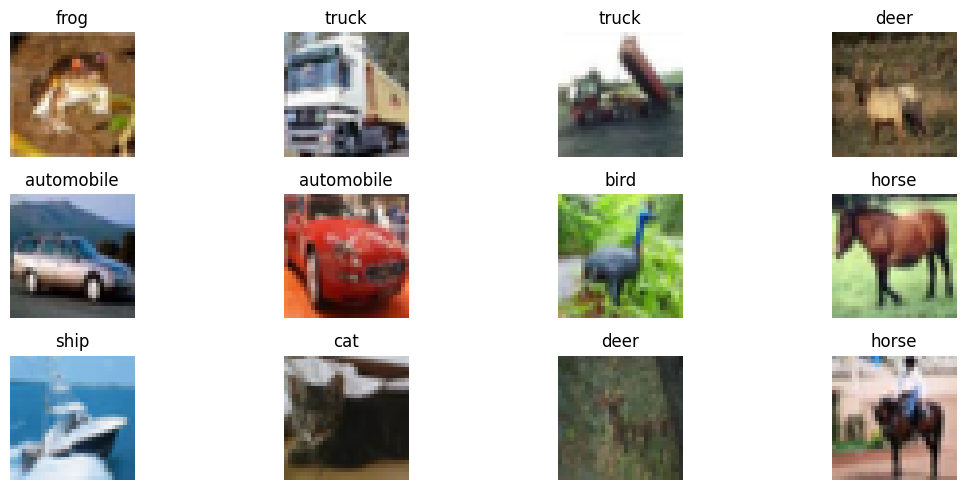

In [6]:
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 3) Data Preprocessing

In [7]:
# Normalize image pixels to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print('x_train:', x_train.shape)
print('x_test :', x_test.shape)
print('y_train_cat:', y_train_cat.shape)
print('y_test_cat :', y_test_cat.shape)

x_train: (50000, 32, 32, 3)
x_test : (10000, 32, 32, 3)
y_train_cat: (50000, 10)
y_test_cat : (10000, 10)


#### 4) Build Configurable CNN Model

In [8]:
def build_cnn_model(
    input_shape=(32, 32, 3),
    num_classes=10,
    filters=(32, 64),
    kernel_size=3,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=1e-3,
    optimizer_name='adam'
):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    for f in filters:
        model.add(layers.Conv2D(f, (kernel_size, kernel_size), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))

    if optimizer_name.lower() == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f'Unsupported optimizer: {optimizer_name}')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#### 5) Hyperparameter Experiments

In [9]:
experiment_configs = [
    {
        'name': 'Exp_1_adam_k3_2layers',
        'filters': (32, 64),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_2_adam_k5_2layers',
        'filters': (32, 64),
        'kernel_size': 5,
        'dropout_rate': 0.35,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_3_rmsprop_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.40,
        'learning_rate': 1e-3,
        'optimizer_name': 'rmsprop'
    },
    {
        'name': 'Exp_4_sgd_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 5e-3,
        'optimizer_name': 'sgd'
    },
    {
        'name': 'Exp_5_adam_lowLR_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.25,
        'learning_rate': 5e-4,
        'optimizer_name': 'adam'
    }
]

EPOCHS = 10
BATCH_SIZE = 128

results = []
histories = {}
trained_models = {}

for cfg in experiment_configs:
    print('\n' + '=' * 80)
    print('Running:', cfg['name'])

    model = build_cnn_model(
        filters=cfg['filters'],
        kernel_size=cfg['kernel_size'],
        dropout_rate=cfg['dropout_rate'],
        learning_rate=cfg['learning_rate'],
        optimizer_name=cfg['optimizer_name']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    ]

    history = model.fit(
        x_train,
        y_train_cat,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(x_train[-5000:], y_train_cat[-5000:], verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    results.append({
        'Experiment': cfg['name'],
        'Optimizer': cfg['optimizer_name'],
        'Learning Rate': cfg['learning_rate'],
        'Kernel Size': cfg['kernel_size'],
        'Conv Layers': len(cfg['filters']),
        'Filters': str(cfg['filters']),
        'Dropout': cfg['dropout_rate'],
        'Validation Accuracy': val_acc,
        'Test Accuracy': test_acc,
        'Validation Loss': val_loss,
        'Test Loss': test_loss
    })

    histories[cfg['name']] = history.history
    trained_models[cfg['name']] = model

results_df = pd.DataFrame(results).sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)
results_df


Running: Exp_1_adam_k3_2layers


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 101ms/step - accuracy: 0.3812 - loss: 1.8130 - val_accuracy: 0.2620 - val_loss: 3.7141
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.5676 - loss: 1.2166 - val_accuracy: 0.5268 - val_loss: 1.6344
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.6289 - loss: 1.0407 - val_accuracy: 0.4832 - val_loss: 1.9681
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.6770 - loss: 0.9102 - val_accuracy: 0.6212 - val_loss: 1.1425
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.7112 - loss: 0.8153 - val_accuracy: 0.6406 - val_loss: 1.0807
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.7430 - loss: 0.7298 - val_accuracy: 0.6598 - val_loss: 1.0353
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.7659 - loss: 0.6599 - val_accuracy: 0.6492 - val_loss: 1.1478
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.7903 - loss: 0.5861 

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Validation Accuracy,Test Accuracy,Validation Loss,Test Loss
0,Exp_4_sgd_k3_3layers,sgd,0.0050,3,3,"(32, 64, 128)",0.30,0.7354,0.7175,0.815990,0.864442
1,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.7344,0.7132,0.828773,0.882319
2,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.7254,0.7097,0.889880,0.960759
3,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.6598,0.6402,1.035272,1.092042
4,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.35,0.6202,0.6019,1.143763,1.178273


#### 6) Compare Experiment Results

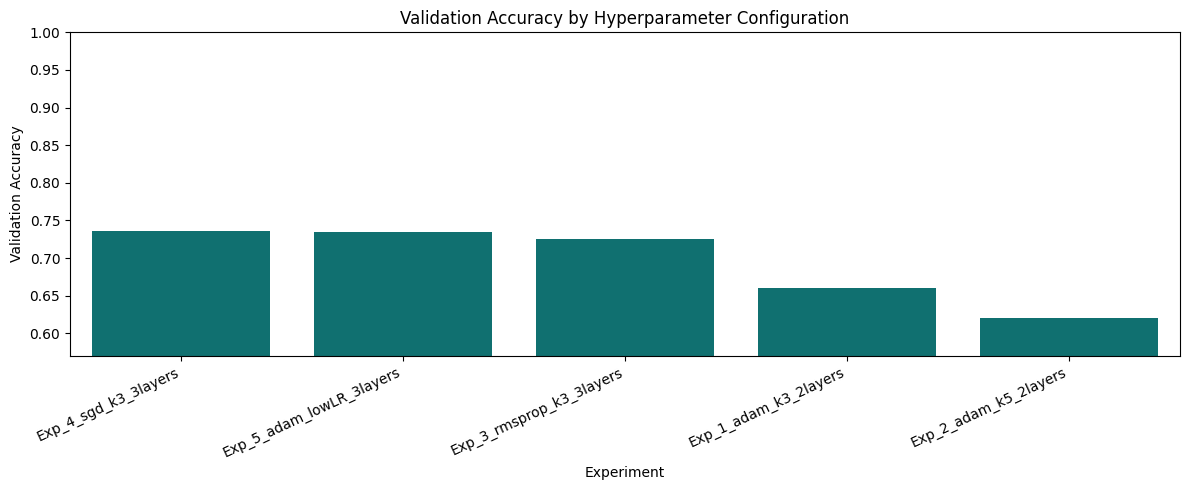

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Validation Accuracy,Test Accuracy,Validation Loss,Test Loss
0,Exp_4_sgd_k3_3layers,sgd,0.0050,3,3,"(32, 64, 128)",0.30,0.7354,0.7175,0.815990,0.864442
1,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.7344,0.7132,0.828773,0.882319
2,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.7254,0.7097,0.889880,0.960759
3,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.6598,0.6402,1.035272,1.092042
4,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.35,0.6202,0.6019,1.143763,1.178273


In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Experiment', y='Validation Accuracy', color='teal')
plt.xticks(rotation=25, ha='right')
plt.ylim(max(0.3, results_df['Validation Accuracy'].min() - 0.05), 1.0)
plt.title('Validation Accuracy by Hyperparameter Configuration')
plt.tight_layout()
plt.show()

display(results_df)

In [11]:
best_experiment = results_df.loc[0, 'Experiment']
best_model = trained_models[best_experiment]
print('Best Experiment:', best_experiment)
print(results_df.loc[0])

Best Experiment: Exp_4_sgd_k3_3layers
Experiment             Exp_4_sgd_k3_3layers
Optimizer                               sgd
Learning Rate                         0.005
Kernel Size                               3
Conv Layers                               3
Filters                       (32, 64, 128)
Dropout                                 0.3
Validation Accuracy                  0.7354
Test Accuracy                        0.7175
Validation Loss                     0.81599
Test Loss                          0.864442
Name: 0, dtype: object


#### 7) Final Evaluation (Best Model)

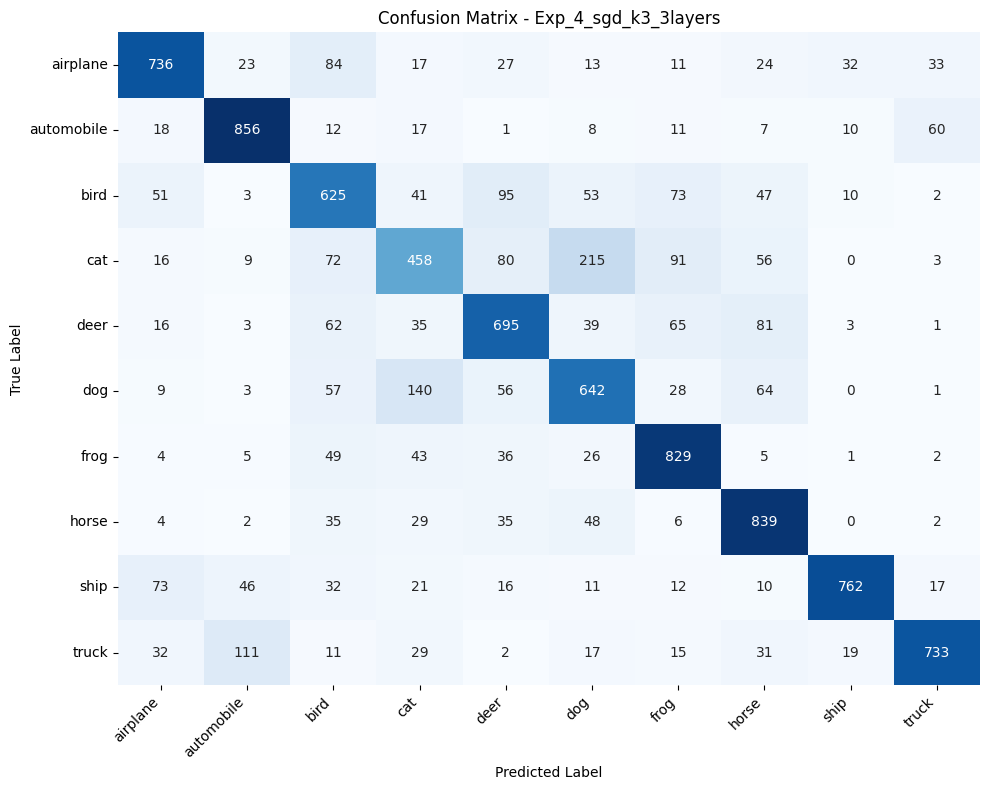

Classification Report:

              precision    recall  f1-score   support

    airplane     0.7675    0.7360    0.7514      1000
  automobile     0.8068    0.8560    0.8307      1000
        bird     0.6015    0.6250    0.6130      1000
         cat     0.5518    0.4580    0.5005      1000
        deer     0.6663    0.6950    0.6804      1000
         dog     0.5989    0.6420    0.6197      1000
        frog     0.7266    0.8290    0.7744      1000
       horse     0.7208    0.8390    0.7754      1000
        ship     0.9104    0.7620    0.8296      1000
       truck     0.8583    0.7330    0.7907      1000

    accuracy                         0.7175     10000
   macro avg     0.7209    0.7175    0.7166     10000
weighted avg     0.7209    0.7175    0.7166     10000



In [12]:
y_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_experiment}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

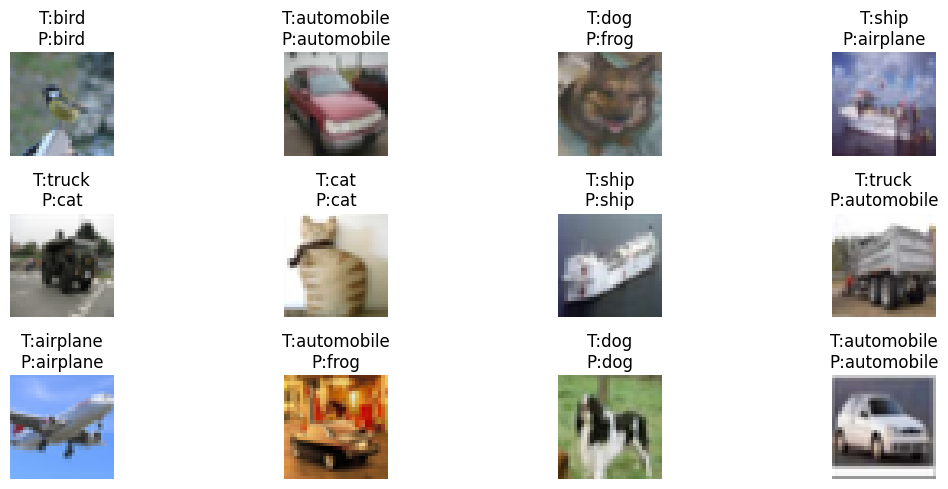

In [13]:
indices = np.random.choice(len(x_test), 12, replace=False)
plt.figure(figsize=(12, 5))

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f'T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()